In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

from datetime import datetime 
import xgboost as xgb

import os

In [2]:
# data = ['transaction_id', 'is_fraud', 'created_at', 'is_subscription', 'transaction_type',
#         'currency_amount', 'currency_id', 'amount_scaled', 'merchant_customer_id',
#         'merchant_country', 'ip_address', 'platform', 'merchant_id', 'merchant_shop_id',
#         'merchant_shop_name', 'is_secured', 'ip_country', 'payment_type', 'card_id', 
#         'bank', 'cardcountry', 'bin', 'card_holder_first_name', 'card_holder_last_name']

data = ['transaction_id', 'is_fraud', 'created_at', 'is_subscription', 'transaction_type',
        'currency_amount', 'currency_id', 'merchant_customer_id',
        'merchant_customer_email', 'merchant_country', 'merchant_language', 'ip_address',
        'platform', 'merchant_id', 'merchant_shop_id', 'merchant_shop_name', 'is_secured',
        'ip_country', 'payment_type', 'user_agent', 'card_id', 'bank', 'cardbrand',
        'cardcountry', 'cardtype', 'bin', 'card_exp_relative', 'card_holder_first_name',
        'card_holder_last_name']

In [ ]:
!python --version

In [3]:
train_path = '/kaggle/input/int20h_test_2025/train.csv' 

In [4]:
total_rows = sum(1 for _ in open(train_path)) - 1  # -1 for header
indices_to_skip = set(np.random.choice(
    range(1, total_rows + 1),  # Skip from row 1 (after header)
    size=int(total_rows * 0.58),  # Skip 58% of rows - 19.3 gb
    replace=False
))

# Read CSV skipping the selected rows
train = pd.read_csv(train_path, 
                 skiprows=lambda x: x in indices_to_skip, usecols=data)

In [ ]:
train.head()

In [6]:
train.isnull().sum()

transaction_id                        0
is_fraud                              0
created_at                            0
is_subscription                       0
transaction_type                      0
currency_amount                       0
currency_id                           0
amount_scaled                         0
merchant_customer_id            1320547
merchant_customer_email               3
merchant_customer_phone         8788260
merchant_customer_first_name    7978219
merchant_customer_last_name     8310152
merchant_country                      1
merchant_city                   8840146
merchant_language               2104469
ip_address                            1
platform                              0
merchant_id                           0
merchant_shop_id                      0
merchant_shop_name                    0
is_secured                            0
order_number                    8704513
ip_country                        34768
is_verified                     9069661


In [8]:
train['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.960776
1    0.039224
Name: proportion, dtype: float64

In [5]:
train.dropna(inplace=True)

In [10]:
train['is_fraud'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [6]:
train.describe()

,transaction_id,is_fraud,currency_amount,currency_id,merchant_id,merchant_shop_id,card_exp_relative
count,3.919600e+04,39196.000000,3.919600e+04,39196.000000,3.919600e+04,39196.000000,39196.000000
mean,9.244028e+18,0.027937,2.076397e+04,111.230023,1.316417e+19,11863.995586,45.509083
std,5.351038e+18,0.164793,5.977268e+04,44.489430,1.674046e+18,7170.432668,20.439770
min,1.960863e+15,0.000000,1.350000e+00,3.000000,8.627844e+16,9.000000,-12.000000
25%,4.589172e+18,0.000000,6.210000e+02,122.000000,1.249847e+19,89.000000,32.000000
50%,9.238003e+18,0.000000,3.913650e+03,122.000000,1.249847e+19,16482.000000,49.000000
75%,1.389541e+19,0.000000,7.508700e+03,122.000000,1.249847e+19,16529.000000,58.000000
max,1.844637e+19,1.000000,3.341250e+06,163.000000,1.760571e+19,19296.000000,371.000000


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_correlations_in_chunks(file_path, chunk_size=5000000):
    first_chunk = True
    correlation_sum = None
    n_chunks = 0
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        chunk_corr = numeric_chunk.corr()
        
        if first_chunk:
            correlation_sum = chunk_corr
            first_chunk = False
        else:
            correlation_sum += chunk_corr
        
        n_chunks += 1
    
    return correlation_sum / n_chunks

def plot_correlation_matrix(correlation_matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

In [7]:
def analyze_fraud_patterns(file_path, target_column='is_fraud', chunk_size=5000000):
    # Initialize statistics dictionaries
    feature_stats = {}
    class_distributions = {0: 0, 1: 0}
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Update class distribution
        class_counts = chunk[target_column].value_counts()
        for label in class_counts.index:
            class_distributions[label] += class_counts[label]
        
        # Calculate statistics for numeric columns
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        for column in numeric_chunk.columns:
            if column != target_column:  # Skip the target column itself
                if column not in feature_stats:
                    feature_stats[column] = {
                        'mean_fraud': [],
                        'mean_normal': [],
                        'std_fraud': [],
                        'std_normal': []
                    }
                
                # Calculate statistics by class
                fraud_stats = numeric_chunk[chunk[target_column] == 1][column].agg(['mean', 'std'])
                normal_stats = numeric_chunk[chunk[target_column] == 0][column].agg(['mean', 'std'])
                
                feature_stats[column]['mean_fraud'].append(fraud_stats['mean'])
                feature_stats[column]['mean_normal'].append(normal_stats['mean'])
                feature_stats[column]['std_fraud'].append(fraud_stats['std'])
                feature_stats[column]['std_normal'].append(normal_stats['std'])
    
    return feature_stats, class_distributions

In [10]:
def analyze_outliers_by_class(file_path, target_column='is_fraud', chunk_size=5000000):
    outlier_stats = {}
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        
        for column in numeric_chunk.columns:
            if column != target_column:
                if column not in outlier_stats:
                    outlier_stats[column] = {'fraud_outliers': 0, 'normal_outliers': 0, 'total_rows': 0}
                
                # Calculate IQR for outlier detection
                Q1 = numeric_chunk[column].quantile(0.25)
                Q3 = numeric_chunk[column].quantile(0.75)
                IQR = Q3 - Q1
                
                # Count outliers by class
                outliers = (numeric_chunk[column] < (Q1 - 1.5 * IQR)) | (numeric_chunk[column] > (Q3 + 1.5 * IQR))
                outlier_stats[column]['fraud_outliers'] += sum(outliers & (chunk[target_column] == 1))
                outlier_stats[column]['normal_outliers'] += sum(outliers & (chunk[target_column] == 0))
                outlier_stats[column]['total_rows'] += len(chunk)
    
    return outlier_stats

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


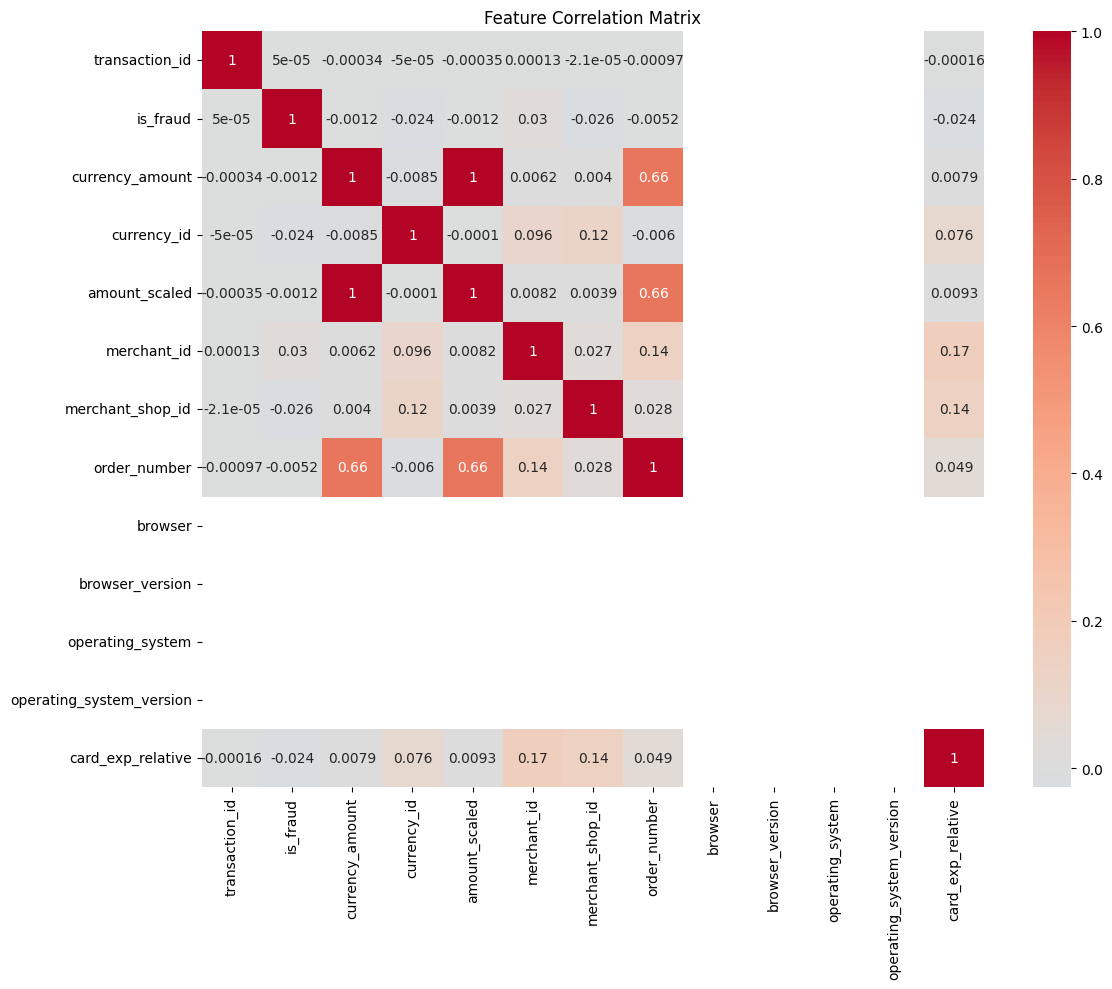

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [14]:
# Run the analyses


# 1. Correlation Analysis
correlation_matrix = analyze_correlations_in_chunks(train_path)
plot_correlation_matrix(correlation_matrix)

In [13]:
# 2. Fraud Patterns Analysis
feature_stats, class_distribution = analyze_fraud_patterns(train_path)

In [11]:
# 3. Outlier Analysis
outlier_stats = analyze_outliers_by_class(train_path)

In [12]:
print("\nOutlier Analysis:")
for column, stats in outlier_stats.items():
    fraud_rate = stats['fraud_outliers'] / stats['total_rows'] * 100
    normal_rate = stats['normal_outliers'] / stats['total_rows'] * 100
    print(f"{column}: Fraud outlier rate: {fraud_rate:.2f}%, Normal outlier rate: {normal_rate:.2f}%")


Outlier Analysis:
transaction_id: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
currency_amount: Fraud outlier rate: 0.51%, Normal outlier rate: 13.50%
currency_id: Fraud outlier rate: 0.84%, Normal outlier rate: 19.08%
amount_scaled: Fraud outlier rate: 0.17%, Normal outlier rate: 3.73%
merchant_id: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
merchant_shop_id: Fraud outlier rate: 0.47%, Normal outlier rate: 8.33%
order_number: Fraud outlier rate: 0.01%, Normal outlier rate: 0.53%
browser: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
browser_version: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
operating_system: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
operating_system_version: Fraud outlier rate: 0.00%, Normal outlier rate: 0.00%
card_exp_relative: Fraud outlier rate: 0.00%, Normal outlier rate: 0.80%


In [14]:
# Print key findings
print("\nClass Distribution (Fraud vs Normal):")
print(class_distribution)


Class Distribution (Fraud vs Normal):
{0: 34964157, 1: 1423743}


In [15]:
print("\nFeature Statistics:")
for feature, stats in feature_stats.items():
    print(f"\n{feature}:")
    print(f"Fraud transactions - Mean: {np.mean(stats['mean_fraud']):.3f}, Std: {np.mean(stats['std_fraud']):.3f}")
    print(f"Normal transactions - Mean: {np.mean(stats['mean_normal']):.3f}, Std: {np.mean(stats['std_normal']):.3f}")


Feature Statistics:

transaction_id:
Fraud transactions - Mean: 9225634944855027712.000, Std: 5322059163183650816.000
Normal transactions - Mean: 9224382356041893888.000, Std: 5324985058052206592.000

currency_amount:
Fraud transactions - Mean: 69892.420, Std: 1357606.040
Normal transactions - Mean: 176821.370, Std: 17888098.210

currency_id:
Fraud transactions - Mean: 118.812, Std: 32.584
Normal transactions - Mean: 122.668, Std: 30.818

amount_scaled:
Fraud transactions - Mean: 3418.122, Std: 3971.471
Normal transactions - Mean: 85947.730, Std: 13221049.566

merchant_id:
Fraud transactions - Mean: 10637577456712058880.000, Std: 4450516145692537856.000
Normal transactions - Mean: 9906895508865826816.000, Std: 4767673051272890368.000

merchant_shop_id:
Fraud transactions - Mean: 13660.283, Std: 5088.312
Normal transactions - Mean: 14264.559, Std: 4463.737

order_number:
Fraud transactions - Mean: 1248591.303, Std: 29608274.068
Normal transactions - Mean: 4465594.965, Std: 96675391.601

In [7]:
def create_amount_features(df):
    # Transaction amount percentiles/stats per merchant
    df['amount_to_merchant_mean'] = df.groupby('merchant_id')['currency_amount'].transform('mean')
    df['amount_to_merchant_std'] = df.groupby('merchant_id')['currency_amount'].transform('std')
    
    # Ratio features
    df['amount_to_merchant_ratio'] = df['currency_amount'] / (df['amount_to_merchant_mean'] + 1e-8)

In [8]:
def create_merchant_features(df):
    # Merchant transaction frequency
    df['merchant_tx_count'] = df.groupby('merchant_id')['transaction_id'].transform('count')
    
    # Merchant-currency patterns
    df['merchant_currency_ratio'] = df.groupby(['merchant_id', 'currency_id'])['transaction_id'].transform('count') / df['merchant_tx_count']
    
    # Merchant shop patterns
    df['merchant_shop_ratio'] = df.groupby(['merchant_id', 'merchant_shop_id'])['transaction_id'].transform('count') / df['merchant_tx_count']

In [9]:
def create_card_features(df):
    # Card usage patterns
    df['card_merchant_count'] = df.groupby('card_exp_relative')['merchant_id'].transform('nunique')
    df['card_currency_count'] = df.groupby('card_exp_relative')['currency_id'].transform('nunique')
    
    # Card amount patterns
    df['card_amount_mean'] = df.groupby('card_exp_relative')['currency_amount'].transform('mean')
    df['card_amount_std'] = df.groupby('card_exp_relative')['currency_amount'].transform('std')

In [10]:
def encode_categorical_features(df):
    from sklearn.preprocessing import LabelEncoder
    
    # Target encoding for high-cardinality features
    df['browser_fraud_rate'] = df.groupby('browser')['is_fraud'].transform('mean')
    df['os_fraud_rate'] = df.groupby('operating_system')['is_fraud'].transform('mean')
    
    # Frequency encoding
    df['browser_freq'] = df.groupby('browser')['transaction_id'].transform('count') / len(df)
    df['os_freq'] = df.groupby('operating_system')['transaction_id'].transform('count') / len(df)

In [11]:
def create_interaction_features(df):
    # Interaction between amount and merchant features
    df['amount_merchant_interaction'] = df['currency_amount'] * df['merchant_tx_count']
    
    # Currency-amount interactions
    df['currency_amount_interaction'] = df['currency_id'].astype(str) + '_' + df['currency_amount'].astype(str)
    
    # Time-based interactions (if you have timestamp)
    # df['hour_amount_interaction'] = df['hour'] * df['amount_scaled']

In [12]:
def create_anomaly_features(df):
    from scipy import stats
    
    # Z-score for amounts
    df['amount_zscore'] = stats.zscore(df['currency_amount'])
    
    # Isolation Forest anomaly score
    from sklearn.ensemble import IsolationForest
    df['isolation_score'] = IsolationForest().fit_predict(df[['currency_amount', 'merchant_tx_count']])

In [13]:
def engineer_features(df):
    df = df.copy()
    
    create_amount_features(df)
    create_merchant_features(df)
    create_card_features(df)
    # encode_categorical_features(df)
    create_interaction_features(df)
    create_anomaly_features(df)
    
    return df

# Apply feature engineering
df_engineered = engineer_features(train)

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

def train_xgboost(train_path, chunk_size=5000000):
    # Create DMatrix in chunks
    dtrain = None
    print("Creating DMatrix...")
    
    for chunk in pd.read_csv(train_path, chunksize=chunk_size):
        # Apply feature engineering
        chunk = engineer_features(chunk)
        
        # Prepare features
        X_chunk = chunk.select_dtypes(include=[np.number])
        y_chunk = X_chunk.pop('is_fraud')
        
        # Convert to DMatrix
        if dtrain is None:
            dtrain = xgb.DMatrix(X_chunk, label=y_chunk)
        else:
            dtrain.extend(xgb.DMatrix(X_chunk, label=y_chunk))
    
    # Set parameters for fraud detection
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': class_ratio,  # handle class imbalance
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'tree_method': 'hist',  # for faster training
        'grow_policy': 'lossguide',  # for better performance
        'max_bin': 256  # for memory efficiency
    }
    
    # Train model
    print("Training XGBoost...")
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=[(dtrain, 'train')],
        early_stopping_rounds=10
    )
    
    return model

In [16]:
test_path = '/kaggle/input/int20h_test_2025/test.csv'

In [ ]:
def evaluate_xgboost(model, test_path, chunk_size=5000000):
    y_true_all = []
    y_pred_all = []
    
    print("Evaluating model...")
    for chunk in pd.read_csv(test_path, chunksize=chunk_size):
        # Apply feature engineering
        chunk = engineer_features(chunk)
        
        # Prepare features
        X_chunk = chunk.select_dtypes(include=[np.number])
        y_chunk = X_chunk.pop('is_fraud')
        
        # Predict
        dtest = xgb.DMatrix(X_chunk)
        y_pred = model.predict(dtest)
        
        # Collect results
        y_true_all.extend(y_chunk)
        y_pred_all.extend(y_pred > 0.5)  # Convert probabilities to binary predictions
    
    # Print evaluation metrics
    print("\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all))
    
    print("\nROC AUC Score:")
    print(roc_auc_score(y_true_all, y_pred_all))

In [ ]:
# Feature importance analysis
def analyze_feature_importance(model, feature_names):
    importance = model.get_score(importance_type='gain')
    importance = pd.DataFrame.from_dict(importance, orient='index', columns=['importance'])
    importance = importance.sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(importance.head(10))

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. First, let's calculate the class ratio for XGBoost parameters
def calculate_class_ratio(train_path, chunk_size=100000):
    fraud_count = 0
    total_count = 0
    
    print("Calculating class ratio...")
    for chunk in pd.read_csv(train_path, chunksize=chunk_size, low_memory=False):
        fraud_count += chunk['is_fraud'].sum()
        total_count += len(chunk)
    
    non_fraud_count = total_count - fraud_count
    class_ratio = non_fraud_count / fraud_count if fraud_count > 0 else 1.0
    print(f"Class ratio (non-fraud/fraud): {class_ratio:.2f}")
    return class_ratio

In [ ]:
def train_xgboost(train_path, chunk_size=5000000):
    # Initialize lists to store data
    X_all = []
    y_all = []
    print("Loading data in chunks...")
    
    # Read first chunk to get feature names after engineering
    first_chunk = next(pd.read_csv(train_path, chunksize=chunk_size))
    first_chunk = engineer_features(first_chunk)
    feature_names = first_chunk.select_dtypes(include=[np.number]).columns.tolist()
    feature_names.remove('is_fraud')
    
    # Process chunks
    for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
        # Apply feature engineering
        chunk = engineer_features(chunk)
        
        # Prepare features
        X_chunk = chunk.select_dtypes(include=[np.number])
        y_chunk = X_chunk.pop('is_fraud')
        
        # Store chunk data
        X_all.append(X_chunk)
        y_all.append(y_chunk)
        
        if i % 10 == 0:
            print(f"Processed {i*chunk_size} rows...")
    
    # Concatenate all chunks
    print("Concatenating chunks...")
    X = pd.concat(X_all, axis=0)
    y = pd.concat(y_all, axis=0)
    
    # Create DMatrix
    print("Creating DMatrix...")
    dtrain = xgb.DMatrix(X, label=y, feature_names=feature_names)
    
    # Set parameters for fraud detection
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': class_ratio,  # handle class imbalance
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'tree_method': 'hist',  # for faster training
        'grow_policy': 'lossguide',  # for better performance
        'max_bin': 256  # for memory efficiency
    }
    
    # Train model
    print("Training XGBoost...")
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=[(dtrain, 'train')],
        early_stopping_rounds=10
    )
    
    return model



In [ ]:
# Running the training
try:
    class_ratio = calculate_class_ratio(train_path)
    # Class ratio (non-fraud/fraud): 24.56
    
    # Train model
    print("\nStarting model training...")
    xgb_model = train_xgboost(train_path)
    
    # Save model (optional but recommended)
    xgb_model.save_model('fraud_detection_model.json')
    print("\nModel saved to fraud_detection_model.json")
    
    # Evaluate model
    print("\nEvaluating model...")
    evaluate_xgboost(xgb_model, test_path)

except Exception as e:
    print(f"An error occurred: {str(e)}")
    raise

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

def train_simple_xgboost(train_path, test_path, chunk_size=5000000):
    # Load a sample of data for training (adjust sample_chunks based on your memory)
    sample_chunks = 10  # This will load 10 chunks, adjust as needed
    
    print("Loading and preparing data...")
    # Load training data
    chunks = []
    for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
        if i >= sample_chunks:
            break
        chunks.append(chunk)
    df = pd.concat(chunks)
    
    # Prepare features
    X = df.select_dtypes(include=[np.number])
    y = X.pop('is_fraud')
    
    print("Training XGBoost model...")
    # Create and train model
    model = xgb.XGBClassifier(
        scale_pos_weight=len(y[y==0])/len(y[y==1]),  # Handle class imbalance
        tree_method='hist',  # For faster training
        max_depth=6,
        learning_rate=0.1
    )
    model.fit(X, y)
    
    print("Evaluating model...")
    # Load and evaluate on test data
    test_chunks = []
    for i, chunk in enumerate(pd.read_csv(test_path, chunksize=chunk_size)):
        if i >= 2:  # Testing on 2 chunks for quick evaluation
            break
        test_chunks.append(chunk)
    test_df = pd.concat(test_chunks)
    
    X_test = test_df.select_dtypes(include=[np.number])
    y_test = X_test.pop('is_fraud')
    
    # Make predictions and print results
    y_pred = model.predict(X_test)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return model

In [ ]:
# Run the training
try:
    model = train_simple_xgboost(train_path, test_path)
    print("Training completed!")
except Exception as e:
    print(f"An error occurred: {str(e)}")

Loading and preparing data...


<ipython-input-17-c62f735117a1>:13: DtypeWarning: Columns (24,27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
<ipython-input-17-c62f735117a1>:13: DtypeWarning: Columns (24,25,27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
<ipython-input-17-c62f735117a1>:13: DtypeWarning: Columns (24,25,27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
<ipython-input-17-c62f735117a1>:13: DtypeWarning: Columns (24,25,27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(train_path, chunksize=chunk_size)):
